<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/07_ML_Kmeans_Hierarchical_Consensus_Clustering/%20Genomics_TCGA_BRCA_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# File download
!wget -o umap_result.csv https://raw.githubusercontent.com/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/refs/heads/main/06_ML_Dimensionality_Reduction/Data/umap_results.csv

In [8]:
import pandas as pd

# step 1:Load your dataset
df = pd.read_csv('umap_results.csv')

# Show first 5 rows
print(df.head())


      UMAP1     UMAP2
0  1.845781  3.529707
1  2.171704  4.253536
2  1.468105  4.292963
3  1.684058  3.277272
4  1.751417  4.405654


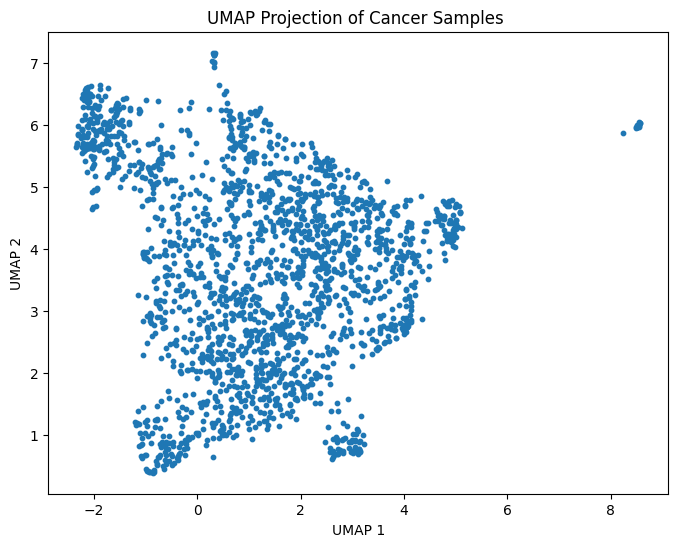

In [10]:
import matplotlib.pyplot as plt

# Step 2: Plot the data points (visulation taki hum jaan sake kitna k-mer kerna hai)
plt.figure(figsize=(8, 6))
plt.scatter(df['UMAP1'], df['UMAP2'], s=10)
plt.title('UMAP Projection of Cancer Samples ')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [14]:
#step 3: kmeans
from sklearn.cluster import KMeans

# Initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Assign each point to a clusters
df['cluster'] = kmeans.fit_predict(df[['UMAP1', 'UMAP2']])

# Print the first 5 rows to see the new 'cluster' column
print(df.head())

      UMAP1     UMAP2  cluster
0  1.845781  3.529707        1
1  2.171704  4.253536        1
2  1.468105  4.292963        1
3  1.684058  3.277272        2
4  1.751417  4.405654        1


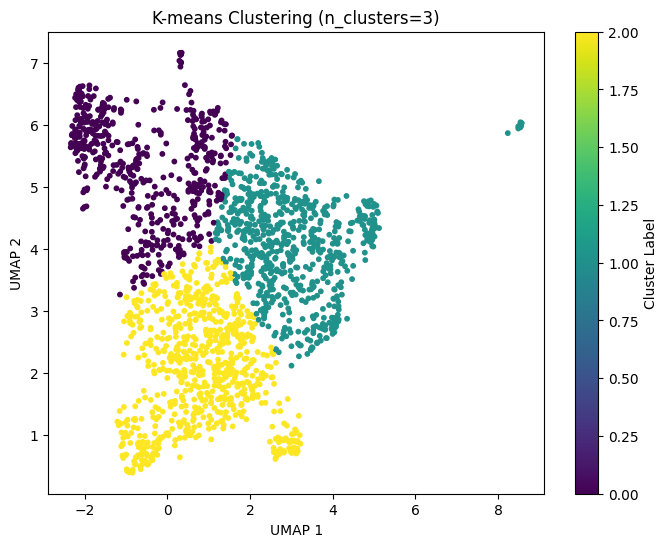

In [16]:
import matplotlib.pyplot as plt

# Step 4: Visualizing the clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['UMAP1'], df['UMAP2'], c=df['cluster'], cmap='viridis', s=10)
plt.title('K-means Clustering (n_clusters=3)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster Label')
plt.show()

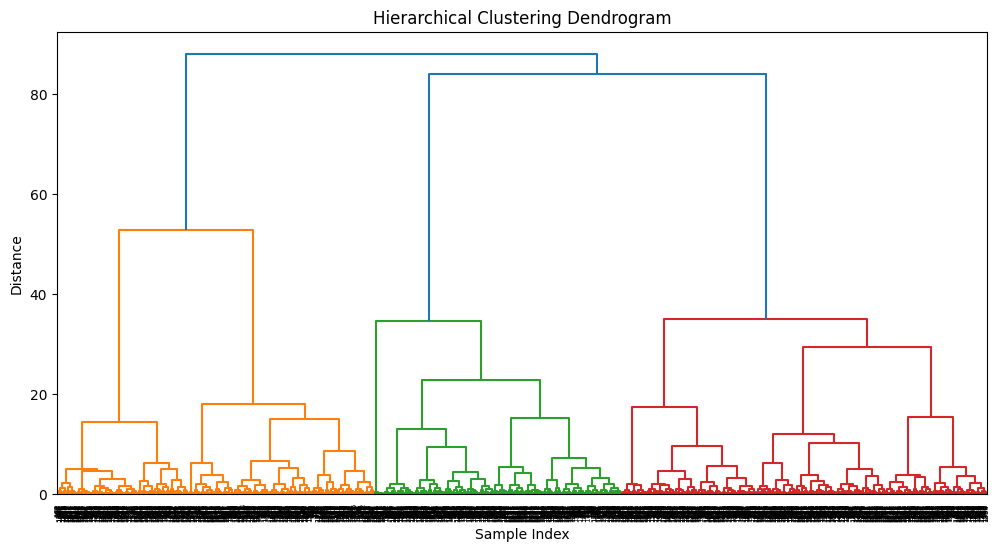

In [18]:
#step 5: Hierarchical Clustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate linkage matrix
# 'ward' method is best to reduce the distance between cluster
Z = linkage(df[['UMAP1', 'UMAP2']], method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

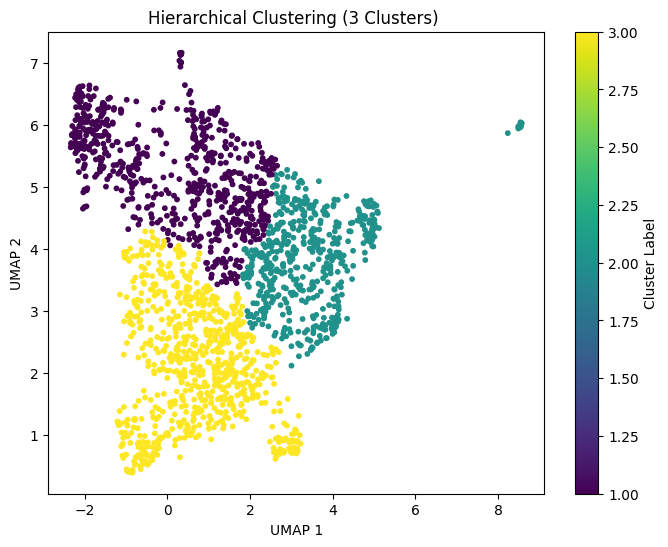

In [19]:
# step 6: Hierarchical clustering subgroup identification
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# 1. Split Hieraechical data into 3 clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

# 2. Show these 3 clusters with colors on graph
plt.figure(figsize=(8, 6))
plt.scatter(df['UMAP1'], df['UMAP2'], c=clusters, cmap='viridis', s=10)
plt.title('Hierarchical Clustering (3 Clusters) ')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster Label')
plt.show()

In [27]:
# step 7: Consensus Clustering
# Install the library
!pip install ConsensusClusterPlus

ERROR: Could not find a version that satisfies the requirement ConsensusClusterPlus (from versions: none)
ERROR: No matching distribution found for ConsensusClusterPlus


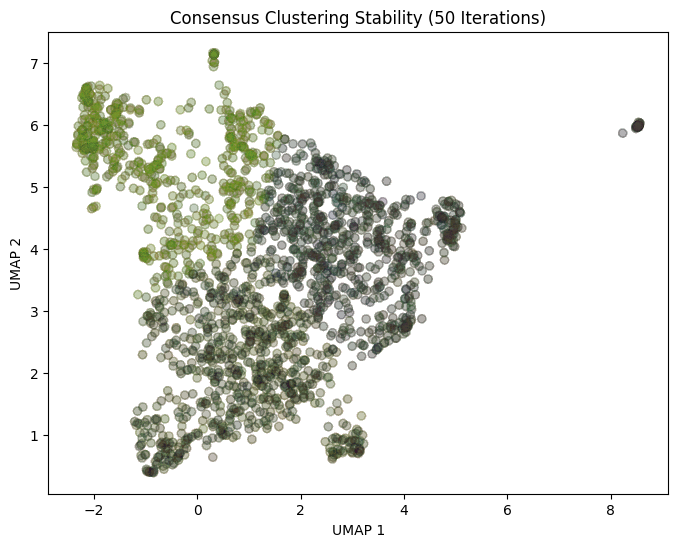

In [28]:
# Clustering Robusses Assesment (Consensus cluatering another type)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Prepare the data
X = df[['UMAP1', 'UMAP2']].values

# Run loop to check stability (50 iterations)
n_iterations = 50
plt.figure(figsize=(8, 6))

for i in range(n_iterations):
    # Take a random 80% sample of the data
    sample_indices = np.random.choice(len(X), size=int(0.8 * len(X)), replace=False)
    X_sample = X[sample_indices]

    # Perform K-means clustering
    kmeans = KMeans(n_clusters=3, random_state=None)
    labels = kmeans.fit_predict(X_sample)

    # Plot the results with low alpha for transparency
    plt.scatter(X_sample[:, 0], X_sample[:, 1], c=labels, alpha=0.01, cmap='viridis')

# Add labels and title for professional appearance
plt.title('Consensus Clustering Stability (50 Iterations)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()


In [29]:
# step 8: Cluster Distribution Analysis

# Check how many samples are in each cluster
cluster_counts = df['cluster'].value_counts()
print("Number of samples in each cluster:")
print(cluster_counts)

# If you want to see which samples belong to which cluster
print("\nFirst 10 samples and their assigned cluster:")
print(df[['cluster']].head(10))


Number of samples in each cluster:
cluster
2    739
1    704
0    537
Name: count, dtype: int64

First 10 samples and their assigned cluster:
   cluster
0        1
1        1
2        1
3        2
4        1
5        1
6        0
7        1
8        1
9        0


In [30]:
# 1. Ensure your dataframe has the latest cluster labels
# (Assumed that your final clustering result is stored in a column named 'cluster')
# If your labels are stored in a variable, add them to the dataframe:
# df['cluster'] = your_final_labels_variable

# 2. Check if the 'cluster' column exists
if 'cluster' in df.columns:
    # 3. Save the dataframe to a CSV file
    df.to_csv('final_clustered_data.csv', index=False)
    print("Success! Your data with cluster labels is saved as 'final_clustered_data.csv'.")
else:
    print("Error: The 'cluster' column is missing. Please make sure you assigned labels to 'df['cluster']'.")


Success! Your data with cluster labels is saved as 'final_clustered_data.csv'.
